# Avoiding Posterior Collapse: When a Powerful Decoder Ignores the Latent Code

## Real-World Scenario: Latent Codes for DNA Regulatory Sequences

**From PML-2 Chapter 21.4**

Imagine we are building a generative model of short **regulatory DNA sequences** — the kind of ~25 bp windows that sit upstream of genes and carry transcription-factor (TF) binding motifs. Our library was assembled from **three TF families**, each leaving a characteristic motif + background composition. We want a VAE whose **latent code $\mathbf{z}$** captures *which regulatory program a sequence belongs to*, so that later we can cluster motifs, interpolate between programs, or sample new candidate enhancers.

Sequences are naturally modelled with an **autoregressive decoder** — a GRU/RNN that predicts each base from the ones before it (exactly the VAE-RNN of §21.3.5). But here is the trap the book warns about in §21.4:

> *If the decoder $p_{\boldsymbol\theta}(\mathbf{x}\mid\mathbf{z})$ is sufficiently powerful (e.g., an RNN for text), then the VAE does not need to use the latent code $\mathbf{z}$ for anything. This is called **posterior collapse** or **variational overpruning**.*

An autoregressive decoder can model the *marginal* base statistics on its own. The KL term in the ELBO charges the model for every bit it stores in $\mathbf{z}$, so the optimizer happily sets $q_{\boldsymbol\phi}(\mathbf{z}\mid\mathbf{x}) \approx p(\mathbf{z})$, drives the KL to zero, and learns **nothing** in the latent space — the very thing we wanted.

In this notebook we will:
1. **Reproduce posterior collapse** with a vanilla ELBO + a strong autoregressive decoder — the latent ends up carrying *zero* information about the TF family.
2. **Fix it three ways from §21.4**: **KL annealing** (§21.4.1), **cyclical annealing**, and **free bits** (§21.4.3).
3. **Measure** collapse with the rate $D_{\mathrm{KL}}$, the number of active units, a linear probe for family identity, and a "does the decoder actually read $\mathbf{z}$?" test.


In [1]:
import os
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)
np.random.seed(0)

plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['font.family'] = 'DejaVu Sans'
%matplotlib inline

device = torch.device('cpu')   # tiny model; CPU is fine
print('torch', torch.__version__)

torch 2.4.1


## Key Formulas from PML-2 §21.4

### The ELBO and the rate (§21.4 intro, Eq. 21.41 specialised to one modality)
$$\mathcal{L}(\boldsymbol\theta,\boldsymbol\phi\mid\mathbf{x}) = \underbrace{\mathbb{E}_{q_{\boldsymbol\phi}(\mathbf{z}\mid\mathbf{x})}\!\left[\log p_{\boldsymbol\theta}(\mathbf{x}\mid\mathbf{z})\right]}_{-\,\text{distortion}} \; - \; \underbrace{D_{\mathrm{KL}}\!\left(q_{\boldsymbol\phi}(\mathbf{z}\mid\mathbf{x})\,\|\,p(\mathbf{z})\right)}_{\text{rate } \mathcal{L}_R}$$

**Posterior collapse** is the degenerate optimum where $q_{\boldsymbol\phi}(\mathbf{z}\mid\mathbf{x}) = p(\mathbf{z})$ for every $\mathbf{x}$, so $\mathcal{L}_R = 0$ and the decoder reconstructs from $\mathbf{z}$ it never reads. A powerful $p_{\boldsymbol\theta}(\mathbf{x}\mid\mathbf{z})$ makes this attractive because it can model the data marginal without help from $\mathbf{z}$.

### Fix 1 — KL annealing (§21.4.1)
Scale the rate term by a weight $\beta_t$ that ramps **up** from $0$ (a plain autoencoder, latent free to fill) to $1$ (true MLE objective):
$$\mathcal{L}_{\beta_t} = \mathbb{E}_{q}\!\left[\log p_{\boldsymbol\theta}(\mathbf{x}\mid\mathbf{z})\right] - \beta_t\, D_{\mathrm{KL}}\!\left(q_{\boldsymbol\phi}(\mathbf{z}\mid\mathbf{x})\,\|\,p(\mathbf{z})\right), \qquad \beta_t: 0 \to 1.$$
**Cyclical annealing** repeats this $0\!\to\!1$ ramp several times, warm-starting each cycle from the latent learned in the last.

### Fix 2 — Free bits (§21.4.3, Eqs. 21.58–21.59)
For a factorised posterior, replace the per-dimension KL with a hinge that *stops charging* once a dimension is already below a target rate $\lambda$:
$$\mathcal{L}_R' = \sum_i \max\!\Big(\lambda,\; D_{\mathrm{KL}}\big(q_{\boldsymbol\phi}(z_i\mid\mathbf{x})\,\|\,p(z_i)\big)\Big).$$
Dimensions whose KL is already small are "free" — the model is not pushed to collapse them all the way to the prior.

The book lists more fixes we discuss at the end: **lower-bounding the rate** (§21.4.2, e.g. $\delta$-VAE / von Mises–Fisher posteriors), **skip connections / skip-VAE** (§21.4.4), **more aggressive inference updates** (§21.4.5), and **alternative objectives** like **InfoVAE** (§21.4.6).


## Step 1: Simulate Regulatory Sequences from Three TF Families

We generate $N = 2400$ sequences of length $L = 25$ over the DNA alphabet $\{\mathtt{A},\mathtt{C},\mathtt{G},\mathtt{T}\}$. Each sequence belongs to one of **three TF families**. A family is defined by:

- a **consensus motif** of length 6 planted at a family-specific position, with a small per-base mutation rate (so motifs are recognisable but noisy), and
- a **background composition** — outside the motif, bases are drawn from a family-specific nucleotide frequency vector.

The family label is the *true* generative factor we hope the latent $\mathbf{z}$ will recover. Crucially, an autoregressive decoder can learn the **mixture** of all three families' base statistics directly — which is exactly why it will be tempted to ignore $\mathbf{z}$.


In [2]:
BASES = np.array(list('ACGT'))
base_to_idx = {b: i for i, b in enumerate(BASES)}
VOCAB = 4

L = 25       # sequence length
N = 2400     # number of sequences
N_FAM = 3    # number of TF families

rng = np.random.default_rng(0)

# Each family: a consensus motif, where it sits, and a background composition.
families = [
    dict(motif='TGACTC', pos=4,  bg=[0.40, 0.10, 0.10, 0.40]),  # AT-rich background
    dict(motif='GGGCGG', pos=12, bg=[0.15, 0.35, 0.35, 0.15]),  # GC-rich background
    dict(motif='TATAAA', pos=18, bg=[0.30, 0.20, 0.20, 0.30]),  # TATA-box-like
]
MUT_RATE = 0.08   # per-base motif mutation probability

def sample_sequence(fam):
    f = families[fam]
    seq = rng.choice(VOCAB, size=L, p=f['bg'])           # background draw
    motif = np.array([base_to_idx[b] for b in f['motif']])
    p = f['pos']
    planted = motif.copy()
    mut = rng.random(len(motif)) < MUT_RATE              # noisy motif
    planted[mut] = rng.integers(0, VOCAB, size=mut.sum())
    seq[p:p + len(motif)] = planted
    return seq

labels = rng.integers(0, N_FAM, size=N)
X = np.stack([sample_sequence(int(y)) for y in labels]).astype(np.int64)

print('sequence tensor:', X.shape, '| families:', np.bincount(labels))
for y in range(N_FAM):
    example = ''.join(BASES[X[np.where(labels == y)[0][0]]])
    motif, pos = families[y]['motif'], families[y]['pos']
    print(f'  family {y}  (motif {motif} @ {pos}):  {example}')

sequence tensor: (2400, 25) | families: [767 801 832]
  family 0  (motif TGACTC @ 4):  AAGTTTACTCAACAAGATATGACAA
  family 1  (motif GGGCGG @ 12):  ACGTGCCCAGCGGGGCGGACAGCCA
  family 2  (motif TATAAA @ 18):  CCGCGGTAAAGTGGACCCTATAAAT


A quick sanity check that the families really are distinguishable: we plot the **per-position base frequencies** for each family. The planted motifs show up as sharp, near-deterministic columns; the background regions differ in their A/C/G/T mix. A clustering or supervised model would separate these easily — the open question is whether the **VAE's latent code** will bother to.


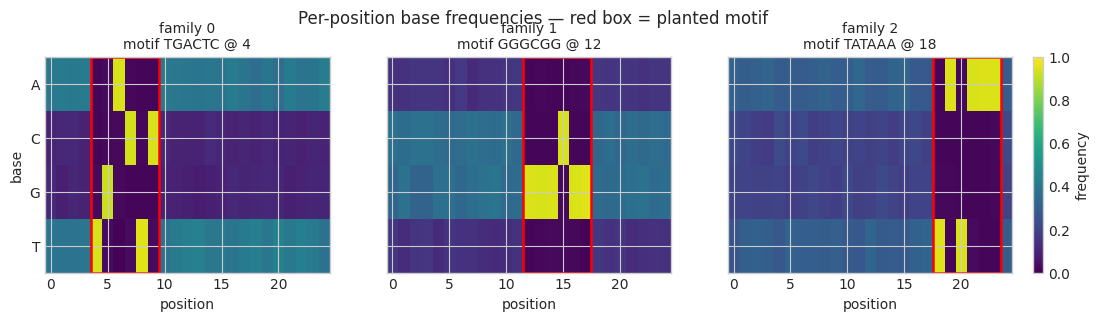

In [3]:
fig, axes = plt.subplots(1, N_FAM, figsize=(13, 2.8), sharey=True)
for y, ax in enumerate(axes):
    sub = X[labels == y]
    freq = np.stack([(sub == b).mean(0) for b in range(VOCAB)])  # (4, L)
    im = ax.imshow(freq, aspect='auto', cmap='viridis', vmin=0, vmax=1)
    ax.set_title(f'family {y}\nmotif {families[y]["motif"]} @ {families[y]["pos"]}', fontsize=10)
    ax.set_xlabel('position')
    ax.set_yticks(range(VOCAB)); ax.set_yticklabels(BASES)
    p = families[y]['pos']
    ax.add_patch(plt.Rectangle((p - 0.5, -0.5), len(families[y]['motif']), VOCAB,
                               fill=False, edgecolor='red', lw=1.8))
axes[0].set_ylabel('base')
fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02, label='frequency')
fig.suptitle('Per-position base frequencies — red box = planted motif', y=1.05)
plt.show()

## Step 2: A VAE with an Autoregressive Decoder (the Collapse-Prone Architecture)

- **Encoder** $q_{\boldsymbol\phi}(\mathbf{z}\mid\mathbf{x})$: a GRU reads the sequence; its final hidden state maps to a **diagonal Gaussian** $\mathcal{N}(\boldsymbol\mu, \mathrm{diag}(\boldsymbol\sigma^2))$ with $K = 8$ latent dimensions.
- **Decoder** $p_{\boldsymbol\theta}(\mathbf{x}\mid\mathbf{z})$: an **autoregressive GRU**. The latent $\mathbf{z}$ is projected to the decoder's *initial hidden state*, then the GRU predicts base $x_t$ from the previous bases $x_{<t}$ (teacher forcing during training). This is the VAE-RNN of §21.3.5 — and the powerful decoder of §21.4.

The key collapse-inducing detail: $\mathbf{z}$ only enters through the **initial hidden state**. The autoregressive path $x_{<t} \to x_t$ is so informative on its own that the model can reach a good likelihood while letting the influence of $\mathbf{z}$ decay away — so the KL term has every incentive to push $q \to p$.


In [4]:
K = 8          # latent dimension
H_ENC = 64     # encoder GRU hidden
H_DEC = 128    # decoder GRU hidden  (deliberately powerful)
EMB = 32
SOS = VOCAB    # start-of-sequence token id (index 4)

class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(VOCAB, EMB)
        self.gru = nn.GRU(EMB, H_ENC, batch_first=True)
        self.head_mu        = nn.Linear(H_ENC, K)
        self.head_log_sigma = nn.Linear(H_ENC, K)

    def forward(self, x):                      # x: (B, L) int64
        _, h = self.gru(self.emb(x))           # h: (1, B, H_ENC)
        h = h.squeeze(0)
        return self.head_mu(h), self.head_log_sigma(h)

class Decoder(nn.Module):
    # Autoregressive GRU: z sets the initial hidden state.
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(VOCAB + 1, EMB)        # +1 for the SOS token
        self.z_to_h = nn.Linear(K, H_DEC)
        self.gru = nn.GRU(EMB, H_DEC, batch_first=True)
        self.out = nn.Linear(H_DEC, VOCAB)

    def forward(self, z, x):                            # teacher forcing
        B = x.size(0)
        sos = torch.full((B, 1), SOS, dtype=torch.long, device=x.device)
        inp = torch.cat([sos, x[:, :-1]], dim=1)        # shift right
        h0 = torch.tanh(self.z_to_h(z)).unsqueeze(0)    # (1, B, H_DEC)
        out, _ = self.gru(self.emb(inp), h0)
        return self.out(out)                            # logits (B, L, VOCAB)

def reparam(mu, log_sigma):
    return mu + torch.randn_like(mu) * log_sigma.exp()

print('encoder params:', sum(p.numel() for p in Encoder().parameters()))
print('decoder params:', sum(p.numel() for p in Decoder().parameters()))

encoder params: 19984
decoder params: 64036


## Step 3: One Loss, Four Rate Treatments

We write a single ELBO routine and control the rate term in two independent ways, matching the book:

- **`beta`** — the KL weight $\beta_t$ for **annealing** (§21.4.1). `beta = 1` is the true ELBO; ramping it $0\!\to\!1$ is linear annealing; a saw-tooth schedule is cyclical annealing.
- **`free_bits`** — the per-dimension floor $\lambda$ for **free bits** (§21.4.3). With $\lambda = 0$ this is off; with $\lambda > 0$ the KL of any dimension already below $\lambda$ stops being penalised.

The per-dimension KL of a diagonal Gaussian against $\mathcal{N}(0,1)$ is
$$D_{\mathrm{KL}}\big(q(z_i\mid\mathbf{x})\,\|\,p(z_i)\big) = \tfrac{1}{2}\big(\mu_i^2 + \sigma_i^2 - 1 - 2\log\sigma_i\big).$$


In [5]:
def elbo_terms(enc, dec, x, beta=1.0, free_bits=0.0):
    mu, log_sigma = enc(x)
    z = reparam(mu, log_sigma)
    logits = dec(z, x)
    # distortion: negative log-likelihood of the sequence, summed over positions
    recon = F.cross_entropy(logits.reshape(-1, VOCAB), x.reshape(-1), reduction='none')
    recon = recon.reshape(x.size(0), L).sum(1).mean()          # nats / sequence
    # per-dimension KL, averaged over the batch  -> shape (K,)
    kl_dim = 0.5 * (mu.pow(2) + (2 * log_sigma).exp() - 1.0 - 2 * log_sigma)
    kl_dim = kl_dim.mean(0)
    kl_true = kl_dim.sum()                                      # the real rate (for reporting)
    # free bits: stop charging dims already below lambda
    kl_charged = torch.clamp(kl_dim, min=free_bits).sum() if free_bits > 0 else kl_true
    loss = recon + beta * kl_charged
    return loss, recon.detach(), kl_true.detach(), kl_dim.detach()

X_t = torch.tensor(X, device=device)
y_t = torch.tensor(labels, device=device)
print('ready:', X_t.shape)

ready: torch.Size([2400, 25])


## Step 4: Train Four Models with Identical Architecture

Every model sees the same data, same network, same optimiser, same number of steps — **only the rate treatment differs**:

| model | rate treatment | section |
|---|---|---|
| **vanilla** | $\beta = 1$ throughout | baseline ELBO |
| **linear anneal** | $\beta_t$ ramps $0 \to 1$ over the first 60% of training | §21.4.1 |
| **cyclical anneal** | $\beta_t$ saw-tooths $0 \to 1$ four times | §21.4.1 |
| **free bits** | $\beta = 1$, $\lambda = 0.5$ nats/dim | §21.4.3 |

The schedules below produce $\beta_t$ for each training step.


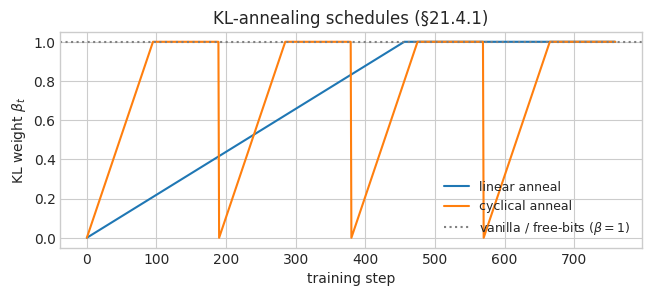

In [6]:
EPOCHS = 40
BATCH = 128
steps_per_epoch = int(np.ceil(N / BATCH))
TOTAL_STEPS = EPOCHS * steps_per_epoch

def schedule_vanilla(step):       return 1.0
def schedule_free_bits(step):     return 1.0     # beta=1; collapse handled by free bits

def schedule_linear(step):
    warm = 0.6 * TOTAL_STEPS
    return min(1.0, step / warm)

def schedule_cyclical(step, n_cycles=4):
    period = TOTAL_STEPS / n_cycles
    frac = (step % period) / period               # 0..1 within a cycle
    return min(1.0, frac / 0.5)                    # ramp up in first half, hold at 1

# Preview the schedules
steps = np.arange(TOTAL_STEPS)
fig, ax = plt.subplots(figsize=(7.5, 2.8))
ax.plot(steps, [schedule_linear(s)   for s in steps], label='linear anneal')
ax.plot(steps, [schedule_cyclical(s) for s in steps], label='cyclical anneal')
ax.axhline(1.0, color='gray', ls=':', label=r'vanilla / free-bits ($\beta=1$)')
ax.set_xlabel('training step'); ax.set_ylabel(r'KL weight $\beta_t$')
ax.set_title(r'KL-annealing schedules (§21.4.1)'); ax.legend(fontsize=9)
plt.show()

In [7]:
def train(beta_fn, free_bits=0.0, seed=0):
    torch.manual_seed(seed)
    enc, dec = Encoder().to(device), Decoder().to(device)
    opt = torch.optim.Adam(list(enc.parameters()) + list(dec.parameters()), lr=2e-3)
    hist = {'recon': [], 'kl': [], 'beta': []}
    step = 0
    for ep in range(EPOCHS):
        perm = torch.randperm(N)
        r_sum = k_sum = 0.0
        for start in range(0, N, BATCH):
            idx = perm[start:start + BATCH]
            x = X_t[idx]
            beta = beta_fn(step)
            opt.zero_grad()
            loss, recon, kl, _ = elbo_terms(enc, dec, x, beta=beta, free_bits=free_bits)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(list(enc.parameters()) + list(dec.parameters()), 5.0)
            opt.step()
            r_sum += recon.item(); k_sum += kl.item(); step += 1
        nb = steps_per_epoch
        hist['recon'].append(r_sum / nb)
        hist['kl'].append(k_sum / nb)
        hist['beta'].append(beta_fn(step - 1))
    return {'enc': enc.eval(), 'dec': dec.eval(), 'hist': hist}

configs = {
    'vanilla':         dict(beta_fn=schedule_vanilla,   free_bits=0.0),
    'linear anneal':   dict(beta_fn=schedule_linear,    free_bits=0.0),
    'cyclical anneal': dict(beta_fn=schedule_cyclical,  free_bits=0.0),
    'free bits (λ=0.5)': dict(beta_fn=schedule_free_bits, free_bits=0.5),
}

models = {}
for name, cfg in configs.items():
    print(f'training: {name} ...')
    models[name] = train(**cfg)
print('done.')

training: vanilla ...


training: linear anneal ...


training: cyclical anneal ...


training: free bits (λ=0.5) ...


done.


## Step 5: The Rate Over Training — Watching the Collapse

The cleanest diagnostic of posterior collapse is the **rate** $\mathcal{L}_R = D_{\mathrm{KL}}(q\,\|\,p)$ as a function of training. Collapse = the rate decaying to (almost) **zero nats**: the latent stores no information.

- **vanilla** should sink toward 0 — the autoregressive decoder swallows the data on its own.
- **annealed / free-bits** models keep a healthy non-zero rate, because the schedule or the hinge protects the latent during the critical early phase.


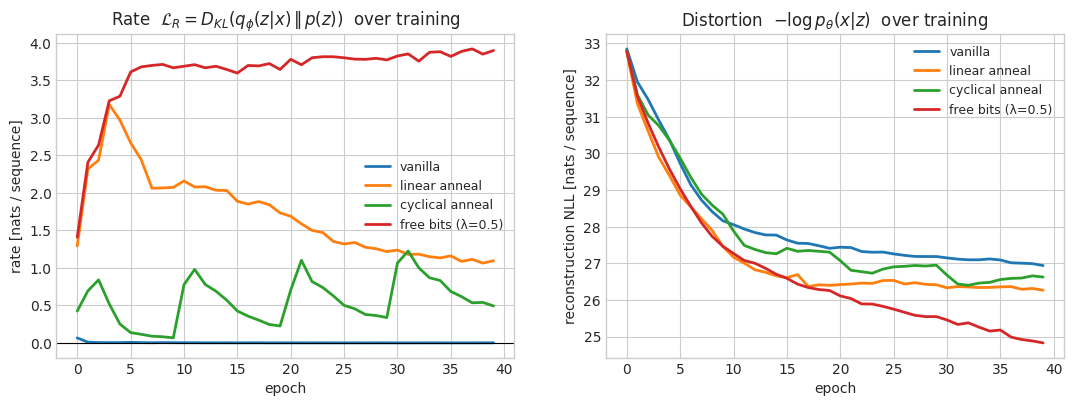

final rate (nats):
  vanilla               KL =  0.002   recon NLL =  26.94
  linear anneal         KL =  1.096   recon NLL =  26.27
  cyclical anneal       KL =  0.493   recon NLL =  26.63
  free bits (λ=0.5)     KL =  3.897   recon NLL =  24.83


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))
for name, m in models.items():
    ax1.plot(m['hist']['kl'], label=name, lw=2)
    ax2.plot(m['hist']['recon'], label=name, lw=2)
ax1.set_title(r'Rate  $\mathcal{L}_R = D_{KL}(q_\phi(z|x)\,\|\,p(z))$  over training')
ax1.set_xlabel('epoch'); ax1.set_ylabel('rate [nats / sequence]')
ax1.axhline(0, color='k', lw=0.8); ax1.legend(fontsize=9)
ax2.set_title('Distortion  $-\\log p_\\theta(x|z)$  over training')
ax2.set_xlabel('epoch'); ax2.set_ylabel('reconstruction NLL [nats / sequence]')
ax2.legend(fontsize=9)
plt.show()

print('final rate (nats):')
for name, m in models.items():
    print(f'  {name:20s}  KL = {m["hist"]["kl"][-1]:6.3f}   recon NLL = {m["hist"]["recon"][-1]:6.2f}')

## Step 6: Active Units — How Many Latent Dimensions Survive?

A latent dimension is **active** if it carries information about $\mathbf{x}$, i.e. its per-dimension KL is meaningfully above zero. We compute $D_{\mathrm{KL}}(q(z_i\mid\mathbf{x})\,\|\,p(z_i))$ averaged over the dataset for each of the $K = 8$ dimensions and count how many clear a small threshold.

Collapse shows up as a bar chart that is **flat at zero**: with the vanilla ELBO essentially every dimension matches the prior. The fixes should keep a handful of dimensions alive — enough to encode the three TF families.


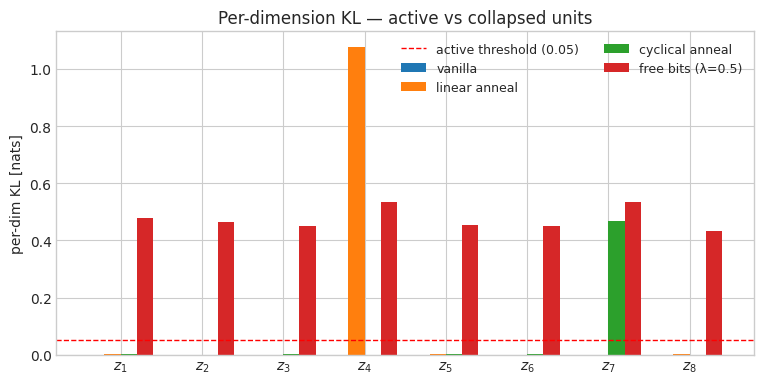

active units (per-dim KL > 0.05):
  vanilla               0 / 8
  linear anneal         1 / 8
  cyclical anneal       1 / 8
  free bits (λ=0.5)     8 / 8


In [9]:
@torch.no_grad()
def per_dim_kl(enc):
    mu, log_sigma = enc(X_t)
    kl = 0.5 * (mu.pow(2) + (2 * log_sigma).exp() - 1.0 - 2 * log_sigma)
    return kl.mean(0).cpu().numpy()

ACTIVE_THRESH = 0.05
fig, ax = plt.subplots(figsize=(9, 4.2))
width = 0.2
xp = np.arange(K)
for i, (name, m) in enumerate(models.items()):
    kld = per_dim_kl(m['enc'])
    ax.bar(xp + (i - 1.5) * width, kld, width=width, label=name)
ax.axhline(ACTIVE_THRESH, color='red', ls='--', lw=1, label=f'active threshold ({ACTIVE_THRESH})')
ax.set_xticks(xp); ax.set_xticklabels([rf'$z_{{{k+1}}}$' for k in range(K)])
ax.set_ylabel('per-dim KL [nats]'); ax.set_title('Per-dimension KL — active vs collapsed units')
ax.legend(fontsize=9, ncol=2)
plt.show()

print('active units (per-dim KL > %.2f):' % ACTIVE_THRESH)
for name, m in models.items():
    kld = per_dim_kl(m['enc'])
    print(f'  {name:20s}  {int((kld > ACTIVE_THRESH).sum())} / {K}')

## Step 7: Does the Latent Carry Family Identity? (Linear Probe)

The rate tells us *how many bits* the latent stores, but not *whether those bits are useful*. The ultimate goal was for $\mathbf{z}$ to encode the **TF family**. So we train a simple **logistic-regression probe** to predict the family label from the posterior mean $\boldsymbol\mu_{\boldsymbol\phi}(\mathbf{x})$ (held-out split).

- A **collapsed** latent → probe accuracy near chance ($1/3 \approx 0.33$): $\boldsymbol\mu$ is the same constant for every sequence.
- A **healthy** latent → high accuracy: the families are linearly separable in latent space.


/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in versio

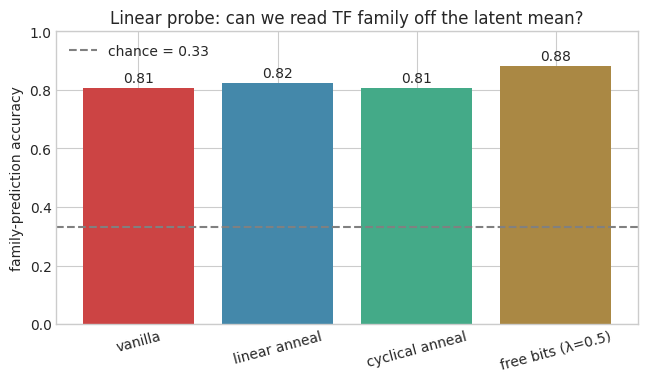

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

@torch.no_grad()
def posterior_means(enc):
    mu, _ = enc(X_t)
    return mu.cpu().numpy()

probe_acc = {}
for name, m in models.items():
    Z = posterior_means(m['enc'])
    Ztr, Zte, ytr, yte = train_test_split(Z, labels, test_size=0.3, random_state=0, stratify=labels)
    clf = LogisticRegression(max_iter=2000, multi_class='multinomial')
    clf.fit(Ztr, ytr)
    probe_acc[name] = clf.score(Zte, yte)

fig, ax = plt.subplots(figsize=(7.5, 3.8))
names = list(probe_acc.keys())
ax.bar(names, [probe_acc[n] for n in names], color=['#c44', '#48a', '#4a8', '#a84'])
ax.axhline(1 / N_FAM, color='gray', ls='--', label=f'chance = {1/N_FAM:.2f}')
ax.set_ylabel('family-prediction accuracy'); ax.set_ylim(0, 1)
ax.set_title('Linear probe: can we read TF family off the latent mean?')
ax.legend()
for i, n in enumerate(names):
    ax.text(i, probe_acc[n] + 0.02, f'{probe_acc[n]:.2f}', ha='center', fontsize=10)
plt.xticks(rotation=15)
plt.show()

## Step 8: Does the Decoder Actually *Read* $\mathbf{z}$?

A complementary, decoder-side test. Take each sequence, encode it to $\boldsymbol\mu$, and measure the decoder's **teacher-forced base accuracy** under two conditions:

1. **with the inferred $\mathbf{z} = \boldsymbol\mu$** — the latent the encoder produced for *this* sequence;
2. **with a prior sample $\mathbf{z} \sim \mathcal{N}(0,\mathbf{I})$** — a latent unrelated to the sequence.

If the decoder genuinely uses the latent, condition (1) should beat condition (2) by a clear margin. Under **posterior collapse**, the decoder ignores its initial hidden state, so the two are **indistinguishable** — the autoregressive path is doing all the work.


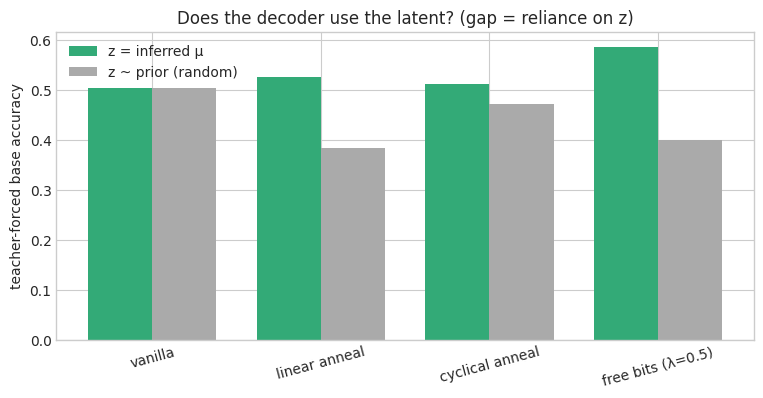

model                  acc(μ)  acc(prior)     gap
vanilla                 0.504       0.503   0.001
linear anneal           0.525       0.384   0.141
cyclical anneal         0.513       0.472   0.041
free bits (λ=0.5)       0.586       0.400   0.186


In [11]:
@torch.no_grad()
def teacher_forced_acc(dec, z, x):
    logits = dec(z, x)
    pred = logits.argmax(-1)
    return (pred == x).float().mean().item()

rows = []
for name, m in models.items():
    mu, _ = m['enc'](X_t)
    acc_true  = teacher_forced_acc(m['dec'], mu, X_t)
    acc_prior = teacher_forced_acc(m['dec'], torch.randn_like(mu), X_t)
    rows.append((name, acc_true, acc_prior, acc_true - acc_prior))

fig, ax = plt.subplots(figsize=(9, 4.0))
xp = np.arange(len(rows))
w = 0.38
ax.bar(xp - w/2, [r[1] for r in rows], width=w, label='z = inferred μ', color='#3a7')
ax.bar(xp + w/2, [r[2] for r in rows], width=w, label='z ~ prior (random)', color='#aaa')
ax.set_xticks(xp); ax.set_xticklabels([r[0] for r in rows], rotation=15)
ax.set_ylabel('teacher-forced base accuracy')
ax.set_title('Does the decoder use the latent? (gap = reliance on z)')
ax.legend()
plt.show()

print(f'{"model":20s} {"acc(μ)":>8s} {"acc(prior)":>11s} {"gap":>7s}')
for name, at, ap, gap in rows:
    print(f'{name:20s} {at:8.3f} {ap:11.3f} {gap:7.3f}')

The **gap** column is the punchline: it is the share of the reconstruction the decoder genuinely draws from $\mathbf{z}$. A near-zero gap for **vanilla** is posterior collapse made concrete — feeding the decoder the *right* latent helps no more than a random one. The annealed and free-bits models open a real gap, confirming the latent is wired into generation.

## Step 9: The Free-Bits Hinge, Visualised (§21.4.3)

Why do free bits work? Equation 21.59 replaces each dimension's KL with $\max(\lambda,\, \mathrm{KL}_i)$. Below $\lambda$ the penalty is **flat**, so its gradient with respect to the KL is **zero** — the optimiser feels no pressure to squeeze that dimension toward the prior, and the latent is free to *grow into* those first $\lambda$ nats. Above $\lambda$ the usual linear penalty resumes.


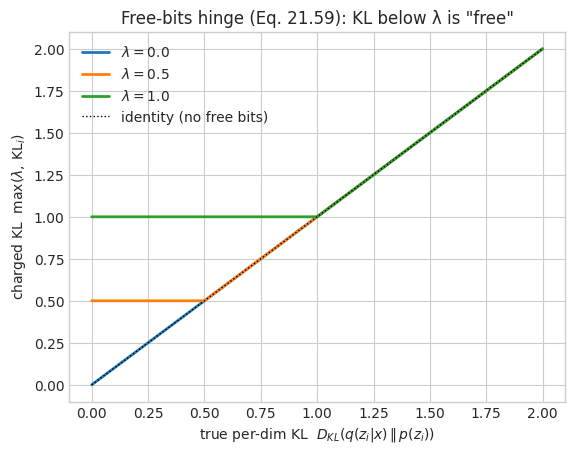

In [12]:
kl_axis = np.linspace(0, 2.0, 400)
for lam in [0.0, 0.5, 1.0]:
    charged = np.maximum(lam, kl_axis)
    plt.plot(kl_axis, charged, lw=2, label=fr'$\lambda = {lam}$')
plt.plot(kl_axis, kl_axis, 'k:', lw=1, label='identity (no free bits)')
plt.xlabel(r'true per-dim KL  $D_{KL}(q(z_i|x)\,\|\,p(z_i))$')
plt.ylabel(r'charged KL  $\max(\lambda,\, \mathrm{KL}_i)$')
plt.title('Free-bits hinge (Eq. 21.59): KL below λ is "free"')
plt.legend(); plt.show()

## The Other Fixes in §21.4 (and Why They Help)

We demonstrated the two most plug-and-play remedies. The chapter lists several more, each attacking collapse from a different angle:

- **§21.4.2 — Lower-bounding the rate.** Instead of penalising the rate less, *constrain the posterior* so it cannot collapse. A **von Mises–Fisher** posterior with fixed concentration $\kappa$ (`vMF`) pins the rate at a constant; the **$\delta$-VAE** uses an autoregressive Gaussian prior whose regression parameter guarantees the rate is at least $\delta$.
- **§21.4.4 — Skip connections (skip-VAE).** Collapse partly happens because $\mathbf{z}$ is weakly *connected* to $\mathbf{x}$. Routing $\mathbf{z}$ directly into many decoder layers (a residual/skip path, Fig. 21.10) keeps its gradient signal strong — our single "initial hidden state" injection is exactly the weak-connection case that collapses most easily.
- **§21.4.5 — Improved variational inference.** Aggressively optimise the **inference network** before each generator step (He et al. 2019), closing the *amortization gap* so the encoder tracks the true posterior and the decoder is encouraged to use latents where they help.
- **§21.4.6 — Alternative objectives (InfoVAE).** Replace the ELBO with an objective (§21.3.2) that adds an explicit term forcing **non-zero mutual information** $\mathbb{I}(\mathbf{x};\mathbf{z})$ — this includes adversarial and **MMD autoencoders** as special cases and directly outlaws the collapsed solution.

A useful mental model: KL annealing and free bits change *when/how much* you pay for the rate; rate lower-bounds and vMF posteriors change *what posteriors are even allowed*; skip connections and better inference change *how easily $\mathbf{z}$ can influence $\mathbf{x}$*; InfoVAE changes *the objective itself*.


## Summary

### What we built
A VAE over short DNA regulatory sequences with an **autoregressive GRU decoder** — the §21.3.5 VAE-RNN — and trained four copies that differ *only* in how the rate term is handled, so we could watch posterior collapse appear and then be cured.

### Key takeaways from PML-2 §21.4
1. **Powerful decoders cause collapse.** An autoregressive decoder models the data marginal on its own, so the vanilla ELBO drives the rate $D_{\mathrm{KL}}(q\,\|\,p) \to 0$ and the latent learns nothing (Step 5). This is **posterior collapse / variational overpruning**.
2. **Collapse is measurable four ways.** A vanishing rate (Step 5), zero active units (Step 6), chance-level probe accuracy (Step 7), and a zero "decoder uses $\mathbf{z}$" gap (Step 8) all tell the same story — and all flip for the fixed models.
3. **KL annealing (§21.4.1).** Ramping $\beta_t: 0 \to 1$ lets the latent fill up while the rate is cheap, then tightens to the true objective. **Cyclical** annealing repeats the ramp, warm-starting each cycle from a useful code.
4. **Free bits (§21.4.3).** The hinge $\max(\lambda, \mathrm{KL}_i)$ stops charging dimensions already below $\lambda$ nats, so they are not pruned to the prior — the flat region has zero gradient (Step 9).
5. **Many roads to the same fix.** Lower-bounding the rate (§21.4.2), skip connections (§21.4.4), better inference (§21.4.5), and InfoVAE-style objectives (§21.4.6) all prevent collapse by constraining the posterior, strengthening the $\mathbf{z}\to\mathbf{x}$ pathway, or rewriting the objective.

### The one-line lesson
Posterior collapse is not a bug in the optimiser — it is a *valid* optimum of the ELBO when the decoder is strong. Avoiding it means changing the game: pay less for the rate early, refuse to let the posterior reach the prior, or wire the latent more firmly into the output.
